In [1]:
import os
import gc
import copy
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import umap.umap_ as umap

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)


Device: mps


In [2]:
DATA_PATH = "proteins_kaggle/proteinas_20000_enriquecido.csv"

data = pd.read_csv(DATA_PATH, index_col=0)
data = data.dropna().copy()

data = data.rename(columns={"Sequência":"Sequence","Massa_Molecular":"Molecular_Weight","Ponto_Isoelétrico":"Isoelectric_Point","Hidrofobicidade":"Hydrophobicity","Carga_Total":"Total_Charge","Proporção_Polar":"Polar_Proportion","Proporção_Apolar":"Nonpolar_Proportion","Comprimento_Sequência":"Sequence_Length","Classe":"class"})
data.index.name = "Protein_ID"

valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

def clean_sequence(sequence):
    sequence = str(sequence).strip().upper()
    return "".join([aa for aa in sequence if aa in valid_amino_acids])

data["Sequence"] = data["Sequence"].map(clean_sequence)
data = data[data["Sequence"].str.len() > 0].copy()

balanced_data = data.groupby("class", group_keys=False).apply(lambda x: x.sample(n=min(6000,len(x)),random_state=SEED)).reset_index()
balanced_data = balanced_data.rename(columns={"index":"Protein_ID"})
balanced_data = balanced_data.set_index("Protein_ID")
balanced_data.index.name = "Protein_ID"

print("Dataset shape:", balanced_data.shape)
print("\nClass counts:")
print(balanced_data["class"].value_counts())
print("\nSequence length summary:")
print(balanced_data["Sequence"].str.len().describe())


Dataset shape: (30000, 9)

Class counts:
class
Enzima        6000
Estrutural    6000
Outras        6000
Receptora     6000
Transporte    6000
Name: count, dtype: int64

Sequence length summary:
count    30000.000000
mean       175.046367
std         72.281686
min         50.000000
25%        113.000000
50%        175.000000
75%        237.000000
max        300.000000
Name: Sequence, dtype: float64


In [3]:
# ==================================================
# HUGGING FACE IMPORTS
# ==================================================

from transformers import (
    AutoTokenizer,
    AutoModel
)

# ==================================================
# ESM-2 MODEL
# ==================================================

MODEL_NAME = "facebook/esm2_t33_650M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME
)

model = model.to(device)

model.eval()


print("Model:", MODEL_NAME)

print(
    "Parameters:",
    sum(p.numel() for p in model.parameters())
)

print(
    "Hidden size:",
    model.config.hidden_size
)

print(
    "Layers:",
    model.config.num_hidden_layers
)

print(
    "Model device:",
    next(model.parameters()).device
)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: facebook/esm2_t33_650M_UR50D
Parameters: 652353941
Hidden size: 1280
Layers: 33
Model device: mps:0


In [8]:
# ==================================================
# ESM-2 PROTEIN EMBEDDING
# ==================================================

@torch.inference_mode()
def embed_sequence_with_esm2(
    sequence,
    max_length=512
):

    sequence = str(sequence).strip().upper()

    if not sequence:
        raise ValueError(
            "Protein sequence is empty."
        )

    inputs = tokenizer(
        sequence,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    outputs = model(**inputs)

    # --------------------------------------------------
    # Residue embeddings
    # --------------------------------------------------

    hidden = outputs.last_hidden_state

    # hidden:
    #
    # (batch, sequence_length, 1280)

    attention_mask = inputs["attention_mask"]

    # Remove padding
    mask = attention_mask.unsqueeze(-1)

    masked_hidden = hidden * mask

    # Mean pooling
    summed = masked_hidden.sum(dim=1)

    counts = mask.sum(
        dim=1
    ).clamp(min=1)

    embedding = summed / counts

    # --------------------------------------------------
    # Final shape
    # --------------------------------------------------

    embedding = embedding.squeeze(0)

    return embedding.float().cpu().numpy()

In [6]:
data.columns

Index(['Sequence', 'Molecular_Weight', 'Isoelectric_Point', 'Hydrophobicity',
       'Total_Charge', 'Polar_Proportion', 'Nonpolar_Proportion',
       'Sequence_Length', 'class'],
      dtype='object')

In [10]:
#sequences = data["Sequence"]

In [13]:
# ==================================================
# TRAIN / TEST SPLIT
# ==================================================

sequences = data["Sequence"]

labels = data["class"]


train_sequences, test_sequences, \
train_labels, test_labels = train_test_split(

    sequences,
    labels,

    test_size=0.2,

    random_state=42
)


train_sequences = train_sequences.reset_index(
    drop=True
)

test_sequences = test_sequences.reset_index(
    drop=True
)

train_labels = train_labels.reset_index(
    drop=True
)

test_labels = test_labels.reset_index(
    drop=True
)


print("Training:", len(train_sequences))
print("Testing :", len(test_sequences))

Training: 48000
Testing : 12000


In [14]:
# ==================================================
# GENERATE ESM-2 EMBEDDINGS
# ==================================================

import numpy as np
from tqdm.auto import tqdm


# --------------------------------------------------
# Embed all sequences
# --------------------------------------------------

embeddings = []

for sequence in tqdm(
    sequences,
    desc="Embedding sequences with ESM-2"
):

    embedding = embed_sequence_with_esm2(
        sequence,
        max_length=512
    )

    embeddings.append(embedding)


# --------------------------------------------------
# Convert to matrix
# --------------------------------------------------

X = np.vstack(
    embeddings
).astype(np.float32)


print("Embedding matrix shape:", X.shape)
print("Embedding dtype:", X.dtype)
print("Embedding dimension:", X.shape[1])

Embedding sequences with ESM-2:   0%|          | 0/60000 [00:00<?, ?it/s]

Embedding matrix shape: (60000, 1280)
Embedding dtype: float32
Embedding dimension: 1280


In [15]:
# ==================================================
# EMBEDDING QUALITY CHECK
# ==================================================

print("Shape:", X.shape)
print("NaN:", np.isnan(X).any())
print("Inf:", np.isinf(X).any())

print(
    "Min:",
    X.min()
)

print(
    "Max:",
    X.max()
)

print(
    "Mean:",
    X.mean()
)

print(
    "Std:",
    X.std()
)

print(
    "Zero rows:",
    np.all(X == 0, axis=1).sum()
)

Shape: (60000, 1280)
NaN: False
Inf: False
Min: -8.782892
Max: 2.0560393
Mean: -0.0017155408
Std: 0.2741188
Zero rows: 0


In [20]:
data["Sequence"]

Protein_ID
P00001    YDRRHIIGFLHFDMQEFITDTAANHTSGSSWEHMELPDTLLPCCEP...
P00002    CLAIWQQFHNWGDEDLTNTSGNCYSAVCGAWSMEAWNVVCYWGFDL...
P00003    QFPGVGNAVQARHMKGTRIHIWIHWARITAIETNQGKNEFPMCTVK...
P00004    HTHIYATIVTWQCNLTQWELQRGAPNVYNWNSNYGYYVHTGLHWYW...
P00005    NWFTYSTLKKTYFLSATGCEKGYAYRLTTYTYIAPWSMNPLNTHIE...
                                ...                        
P59996    QGVLVHQCCLKVQYMWYGGPNFLGNKNSMMVHTYLQYMSMGSVPES...
P59997    KNVVYWHMILLNNHWENWHRTMAESTMGMFPTYFSDHFDQKFLWSL...
P59998    CRLHHMHSGACDRQWDHHFNTDPPTLYKCSEAHYKKGLMSSNIVNM...
P59999    DDRPTLVMTTSHFLRLDNYKWCHNHTWMLVPILTQIPSAQVHTRVN...
P60000    TKDNMIEGWLICKDGDAVSDIQQSHSYMSLYHDKIGGPRFWMICIG...
Name: Sequence, Length: 60000, dtype: object

In [21]:
# ==================================================
# EXPERIMENTAL TRAIN / TEST SPLIT
# ==================================================

from sklearn.model_selection import train_test_split

# --------------------------------------------------
# Sequences and labels
# --------------------------------------------------

sequences = data["Sequence"]

y = data["class"].to_numpy()

# --------------------------------------------------
# Sanity check
# --------------------------------------------------

assert len(X) == len(sequences)
assert len(X) == len(y)

print("Sequences:", len(sequences))
print("Embeddings:", X.shape)
print("Labels:", y.shape)

print("\nClass distribution:")
print(
    data["class"].value_counts().sort_index()
)

# --------------------------------------------------
# Train / test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Verify
# --------------------------------------------------

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining distribution:")
print(
    np.unique(
        y_train,
        return_counts=True
    )
)

print("\nTesting distribution:")
print(
    np.unique(
        y_test,
        return_counts=True
    )
)

Sequences: 60000
Embeddings: (60000, 1280)
Labels: (60000,)

Class distribution:
class
Enzima        11954
Estrutural    11991
Outras        12216
Receptora     11850
Transporte    11989
Name: count, dtype: int64

X_train: (48000, 1280)
X_test : (12000, 1280)
y_train: (48000,)
y_test : (12000,)

Training distribution:
(array(['Enzima', 'Estrutural', 'Outras', 'Receptora', 'Transporte'],
      dtype=object), array([9563, 9593, 9773, 9480, 9591]))

Testing distribution:
(array(['Enzima', 'Estrutural', 'Outras', 'Receptora', 'Transporte'],
      dtype=object), array([2391, 2398, 2443, 2370, 2398]))


In [22]:
# ==================================================
# DIMENSIONALITY EXPERIMENT
# ==================================================

D_VALUES = [
    64,
    128,
    256,
    300,
    360,
    520,
    768,
    1024,
    1280
]

print("ESM-2 embedding dimension:", X.shape[1])
print("Experimental dimensions:", D_VALUES)

assert max(D_VALUES) <= X.shape[1]

ESM-2 embedding dimension: 1280
Experimental dimensions: [64, 128, 256, 300, 360, 520, 768, 1024, 1280]


In [23]:
# ==================================================
# PCA DIMENSIONALITY EXPERIMENT
# ==================================================

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pca_results = []


for D in D_VALUES:

    print(f"\n{'=' * 60}")
    print(f"PCA → D={D}")
    print(f"{'=' * 60}")

    # --------------------------------------------------
    # Fit PCA ONLY on training data
    # --------------------------------------------------

    pca = PCA(
        n_components=D,
        random_state=42
    )

    X_train_D = pca.fit_transform(
        X_train
    ).astype(np.float32)

    X_test_D = pca.transform(
        X_test
    ).astype(np.float32)

    # --------------------------------------------------
    # Classifier
    # --------------------------------------------------

    classifier = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    classifier.fit(
        X_train_D,
        y_train
    )

    # --------------------------------------------------
    # Evaluation
    # --------------------------------------------------

    train_pred = classifier.predict(
        X_train_D
    )

    test_pred = classifier.predict(
        X_test_D
    )

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    explained_variance = (
        pca.explained_variance_ratio_.sum()
    )

    pca_results.append({
        "D": D,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "explained_variance": explained_variance
    })

    print(
        f"Train accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Test accuracy : {test_accuracy:.4f}"
    )

    print(
        f"Explained variance: "
        f"{explained_variance:.4f}"
    )


PCA → D=64
Train accuracy: 0.2193
Test accuracy : 0.1965
Explained variance: 0.9166

PCA → D=128
Train accuracy: 0.2269
Test accuracy : 0.1989
Explained variance: 0.9521

PCA → D=256
Train accuracy: 0.2365
Test accuracy : 0.1953
Explained variance: 0.9738

PCA → D=300
Train accuracy: 0.2380
Test accuracy : 0.1958
Explained variance: 0.9778

PCA → D=360
Train accuracy: 0.2422
Test accuracy : 0.1961
Explained variance: 0.9820

PCA → D=520
Train accuracy: 0.2519
Test accuracy : 0.1958
Explained variance: 0.9893

PCA → D=768
Train accuracy: 0.2632
Test accuracy : 0.1965
Explained variance: 0.9953

PCA → D=1024
Train accuracy: 0.2711
Test accuracy : 0.1966
Explained variance: 0.9985

PCA → D=1280
Train accuracy: 0.2754
Test accuracy : 0.1968
Explained variance: 1.0000


In [24]:
# ==================================================
# LEARNED PROJECTION
# ==================================================

class ESM2Projection(nn.Module):

    def __init__(
        self,
        input_dim=1280,
        hidden_dim=512,
        output_dim=256
    ):

        super().__init__()

        self.projection = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.LayerNorm(
                hidden_dim
            ),

            nn.GELU(),

            nn.Linear(
                hidden_dim,
                output_dim
            )
        )

    def forward(self, x):

        return self.projection(x)

In [25]:
# ==================================================
# LEARNED PROJECTION EXPERIMENT SETTINGS
# ==================================================

EPOCHS = 50
LEARNING_RATE = 1e-3
SEED = 42

learned_results = []

In [27]:
# ============================================================
# LEARNED PROJECTION DIMENSIONALITY EXPERIMENT
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score


# ============================================================
# CONFIGURATION
# ============================================================

INPUT_DIM = 1280
HIDDEN_DIM = 512

EPOCHS = 50
LEARNING_RATE = 1e-3
SEED = 42

D_VALUES = [
    64,
    128,
    256,
    300,
    360,
    520,
    768,
    1024,
    1280
]


# ============================================================
# LABEL CONVERSION
# ============================================================

# Convert labels to a clean integer NumPy array.
#
# This handles cases where y_train/y_test are:
# - pandas Series
# - object arrays
# - strings
# - categorical labels
#
# If y has already been encoded as integers, this preserves
# the integer class values.

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_all = label_encoder.fit_transform(
    data["class"].astype(str)
).astype(np.int64)


print("Classes:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i} -> {class_name}")


# ============================================================
# SANITY CHECK
# ============================================================

assert X.ndim == 2
assert X.shape[1] == INPUT_DIM
assert len(X) == len(y_all)

print("\nEmbedding matrix:")
print("X shape:", X.shape)
print("X dtype:", X.dtype)

print("\nLabels:")
print("y shape:", y_all.shape)
print("y dtype:", y_all.dtype)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_all,

    test_size=0.20,

    random_state=42,

    stratify=y_all
)


# ============================================================
# FORCE NUMPY TYPES
# ============================================================

X_train = np.asarray(
    X_train,
    dtype=np.float32
)

X_test = np.asarray(
    X_test,
    dtype=np.float32
)

y_train = np.asarray(
    y_train,
    dtype=np.int64
)

y_test = np.asarray(
    y_test,
    dtype=np.int64
)


# ============================================================
# VERIFY SPLIT
# ============================================================

print("\nSplit:")
print("X_train:", X_train.shape, X_train.dtype)
print("X_test :", X_test.shape, X_test.dtype)

print("y_train:", y_train.shape, y_train.dtype)
print("y_test :", y_test.shape, y_test.dtype)

print("\nTrain classes:")
print(np.bincount(y_train))

print("\nTest classes:")
print(np.bincount(y_test))


# ============================================================
# PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.from_numpy(
    X_train
).to(
    device=device,
    dtype=torch.float32
)

X_test_tensor = torch.from_numpy(
    X_test
).to(
    device=device,
    dtype=torch.float32
)

y_train_tensor = torch.from_numpy(
    y_train
).to(
    device=device,
    dtype=torch.long
)

y_test_tensor = torch.from_numpy(
    y_test
).to(
    device=device,
    dtype=torch.long
)


print("\nTorch tensors:")
print("X_train_tensor:", X_train_tensor.shape)
print("X_test_tensor :", X_test_tensor.shape)

print("y_train_tensor:", y_train_tensor.shape)
print("y_test_tensor :", y_test_tensor.shape)


# ============================================================
# PROJECTION + CLASSIFIER
# ============================================================

class ESM2ProjectionClassifier(nn.Module):

    def __init__(
        self,
        input_dim=1280,
        hidden_dim=512,
        output_dim=256,
        num_classes=5
    ):

        super().__init__()

        # ----------------------------------------------
        # Learned representation
        # ----------------------------------------------

        self.projection = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.LayerNorm(
                hidden_dim
            ),

            nn.GELU(),

            nn.Linear(
                hidden_dim,
                output_dim
            )
        )

        # ----------------------------------------------
        # Classification head
        # ----------------------------------------------

        self.classifier = nn.Linear(
            output_dim,
            num_classes
        )


    def forward(self, x):

        z = self.projection(x)

        logits = self.classifier(z)

        return logits, z


# ============================================================
# NUMBER OF CLASSES
# ============================================================

NUM_CLASSES = len(
    label_encoder.classes_
)

print("\nNumber of classes:", NUM_CLASSES)


# ============================================================
# RESULTS STORAGE
# ============================================================

learned_results = []


# ============================================================
# RUN DIMENSIONALITY EXPERIMENT
# ============================================================

for D in D_VALUES:

    print("\n" + "=" * 70)
    print(f"LEARNED PROJECTION → D = {D}")
    print("=" * 70)


    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    random.seed(SEED)
    np.random.seed(SEED)

    torch.manual_seed(SEED)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            SEED
        )


    # --------------------------------------------------------
    # Create a NEW model for every D
    # --------------------------------------------------------

    model_projection = ESM2ProjectionClassifier(

        input_dim=INPUT_DIM,

        hidden_dim=HIDDEN_DIM,

        output_dim=D,

        num_classes=NUM_CLASSES

    ).to(device)


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        model_projection.parameters(),
        lr=LEARNING_RATE
    )


    # --------------------------------------------------------
    # Training history
    # --------------------------------------------------------

    history = {
        "train_loss": [],
        "train_accuracy": []
    }


    # ========================================================
    # TRAIN
    # ========================================================

    for epoch in range(EPOCHS):

        model_projection.train()

        optimizer.zero_grad()


        # Forward pass

        logits, z = model_projection(
            X_train_tensor
        )


        # Loss

        loss = criterion(
            logits,
            y_train_tensor
        )


        # Backpropagation

        loss.backward()

        optimizer.step()


        # ----------------------------------------------------
        # Training accuracy
        # ----------------------------------------------------

        predictions = logits.argmax(
            dim=1
        )


        train_accuracy = (
            predictions == y_train_tensor
        ).float().mean().item()


        # ----------------------------------------------------
        # Store history
        # ----------------------------------------------------

        history["train_loss"].append(
            loss.item()
        )

        history["train_accuracy"].append(
            train_accuracy
        )


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            epoch == 0
            or (epoch + 1) % 5 == 0
        ):

            print(
                f"Epoch {epoch + 1:03d} | "
                f"Loss {loss.item():.4f} | "
                f"Train Accuracy {train_accuracy:.4f}"
            )


    # ========================================================
    # TEST
    # ========================================================

    model_projection.eval()

    with torch.inference_mode():

        test_logits, test_z = model_projection(
            X_test_tensor
        )


        test_predictions = test_logits.argmax(
            dim=1
        )


        test_accuracy = (
            test_predictions == y_test_tensor
        ).float().mean().item()


    # --------------------------------------------------------
    # Final training accuracy
    # --------------------------------------------------------

    final_train_accuracy = (
        history["train_accuracy"][-1]
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    learned_results.append({

        "D": D,

        "train_accuracy":
            final_train_accuracy,

        "test_accuracy":
            test_accuracy,

        "final_train_loss":
            history["train_loss"][-1]

    })


    # ========================================================
    # REPORT
    # ========================================================

    print("\nFinal result:")

    print(
        f"D = {D}"
    )

    print(
        f"Train accuracy = "
        f"{final_train_accuracy:.4f}"
    )

    print(
        f"Test accuracy  = "
        f"{test_accuracy:.4f}"
    )


# ============================================================
# RESULTS TABLE
# ============================================================

import pandas as pd

learned_results_df = pd.DataFrame(
    learned_results
)

print("\n")
print(
    learned_results_df.to_string(
        index=False
    )
)

Classes:
  0 -> Enzima
  1 -> Estrutural
  2 -> Outras
  3 -> Receptora
  4 -> Transporte

Embedding matrix:
X shape: (60000, 1280)
X dtype: float32

Labels:
y shape: (60000,)
y dtype: int64

Split:
X_train: (48000, 1280) float32
X_test : (12000, 1280) float32
y_train: (48000,) int64
y_test : (12000,) int64

Train classes:
[9563 9593 9773 9480 9591]

Test classes:
[2391 2398 2443 2370 2398]

Torch tensors:
X_train_tensor: torch.Size([48000, 1280])
X_test_tensor : torch.Size([12000, 1280])
y_train_tensor: torch.Size([48000])
y_test_tensor : torch.Size([12000])

Number of classes: 5

LEARNED PROJECTION → D = 64
Epoch 001 | Loss 1.6267 | Train Accuracy 0.1984
Epoch 005 | Loss 1.6657 | Train Accuracy 0.1975
Epoch 010 | Loss 1.6226 | Train Accuracy 0.2046
Epoch 015 | Loss 1.6170 | Train Accuracy 0.1992
Epoch 020 | Loss 1.6148 | Train Accuracy 0.2057
Epoch 025 | Loss 1.6094 | Train Accuracy 0.2021
Epoch 030 | Loss 1.6113 | Train Accuracy 0.2006
Epoch 035 | Loss 1.6084 | Train Accuracy 0.2114

In [28]:
import random
import numpy as np
import torch
import torch.nn as nn
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("Seed:", SEED)
print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Classes:", np.unique(y_train))

Seed: 42
Train: (48000, 1280)
Test : (12000, 1280)
Classes: [0 1 2 3 4]


In [29]:
class RawESM2Classifier(nn.Module):
    def __init__(self, input_dim=1280, num_classes=5):
        super().__init__()

        self.classifier = nn.Linear(
            input_dim,
            num_classes
        )

    def forward(self, x):
        return self.classifier(x)

In [30]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32,
    device=device
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32,
    device=device
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long,
    device=device
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long,
    device=device
)

In [31]:
model = RawESM2Classifier(
    input_dim=1280,
    num_classes=5
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 50

history = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = criterion(
        logits,
        y_train_tensor
    )

    loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():

        train_logits = model(X_train_tensor)
        test_logits = model(X_test_tensor)

        train_pred = train_logits.argmax(dim=1)
        test_pred = test_logits.argmax(dim=1)

        train_acc = (
            train_pred == y_train_tensor
        ).float().mean().item()

        test_acc = (
            test_pred == y_test_tensor
        ).float().mean().item()

    history.append({
        "epoch": epoch + 1,
        "loss": loss.item(),
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:02d} | "
            f"Loss {loss.item():.4f} | "
            f"Train {train_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

Epoch 10 | Loss 1.6096 | Train 0.2078 | Test 0.2012
Epoch 20 | Loss 1.6083 | Train 0.2149 | Test 0.2011
Epoch 30 | Loss 1.6077 | Train 0.2183 | Test 0.1994
Epoch 40 | Loss 1.6072 | Train 0.2206 | Test 0.2006
Epoch 50 | Loss 1.6068 | Train 0.2220 | Test 0.1984


In [32]:
class RawESM2MLP(nn.Module):
    def __init__(
        self,
        input_dim=1280,
        hidden_dim=512,
        num_classes=5
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [33]:
from sklearn.decomposition import PCA

pca_results = []

for D in D_VALUES:

    print(f"\n===== PCA {D}D =====")

    pca = PCA(
        n_components=D,
        random_state=SEED
    )

    X_train_pca = pca.fit_transform(
        X_train
    ).astype(np.float32)

    X_test_pca = pca.transform(
        X_test
    ).astype(np.float32)

    print(
        "Explained variance:",
        pca.explained_variance_ratio_.sum()
    )

    Xtr = torch.tensor(
        X_train_pca,
        dtype=torch.float32,
        device=device
    )

    Xte = torch.tensor(
        X_test_pca,
        dtype=torch.float32,
        device=device
    )

    model = nn.Linear(D, 5).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    for epoch in range(50):

        model.train()

        optimizer.zero_grad()

        logits = model(Xtr)

        loss = criterion(
            logits,
            y_train_tensor
        )

        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():

        train_pred = model(Xtr).argmax(dim=1)
        test_pred = model(Xte).argmax(dim=1)

    train_acc = (
        train_pred == y_train_tensor
    ).float().mean().item()

    test_acc = (
        test_pred == y_test_tensor
    ).float().mean().item()

    pca_results.append({
        "D": D,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "explained_variance": (
            pca.explained_variance_ratio_.sum()
        )
    })

pca_results_df = pd.DataFrame(pca_results)

pca_results_df


===== PCA 64D =====
Explained variance: 0.91657394

===== PCA 128D =====
Explained variance: 0.9520965

===== PCA 256D =====
Explained variance: 0.97380584

===== PCA 300D =====
Explained variance: 0.9777693

===== PCA 360D =====
Explained variance: 0.98197466

===== PCA 520D =====
Explained variance: 0.98930174

===== PCA 768D =====
Explained variance: 0.9953123

===== PCA 1024D =====
Explained variance: 0.99850905

===== PCA 1280D =====
Explained variance: 1.0000001


,D,train_accuracy,test_accuracy,explained_variance
0,64,0.206146,0.202333,0.916574
1,128,0.213479,0.195333,0.952097
2,256,0.224750,0.198333,0.973806
3,300,0.223708,0.201750,0.977769
4,360,0.226021,0.200333,0.981975
5,520,0.230875,0.202833,0.989302
6,768,0.233896,0.201250,0.995312
7,1024,0.238625,0.199833,0.998509
8,1280,0.241979,0.204667,1.000000


In [34]:
def evaluate_model(model, X, y):

    model.eval()

    with torch.no_grad():
        logits = model(X)
        predictions = logits.argmax(dim=1)

    y_true = y.cpu().numpy()
    y_pred = predictions.cpu().numpy()

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

In [35]:
metrics = evaluate_model(
    model,
    X_test_tensor,
    y_test_tensor
)

metrics

{'accuracy': 0.19933333333333333,
 'balanced_accuracy': 0.19956031105799943,
 'macro_f1': 0.0930200167537095,
 'weighted_f1': 0.09286535099829916}

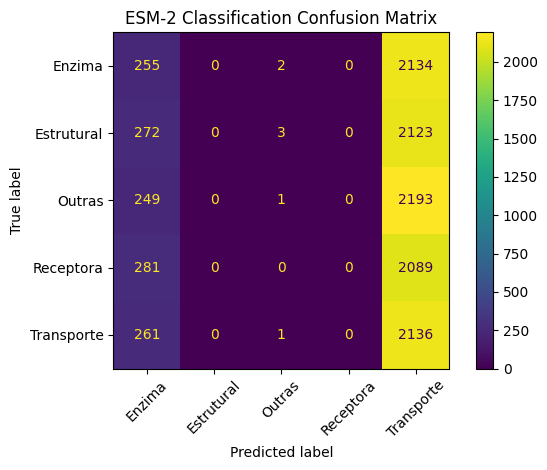

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

model.eval()

with torch.no_grad():
    predictions = (
        model(X_test_tensor)
        .argmax(dim=1)
        .cpu()
        .numpy()
    )

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("ESM-2 Classification Confusion Matrix")
plt.tight_layout()
plt.show()

In [38]:
sequence_lengths = data["Sequence"].astype(str).str.len()

print(
    sequence_lengths.describe()
)

print(
    "Sequences > 512:",
    (sequence_lengths > 512).sum()
)

print(
    "Percentage > 512:",
    100 * (sequence_lengths > 512).mean()
)

count    60000.000000
mean       174.775683
std         72.330865
min         50.000000
25%        112.000000
50%        175.000000
75%        237.000000
max        300.000000
Name: Sequence, dtype: float64
Sequences > 512: 0
Percentage > 512: 0.0


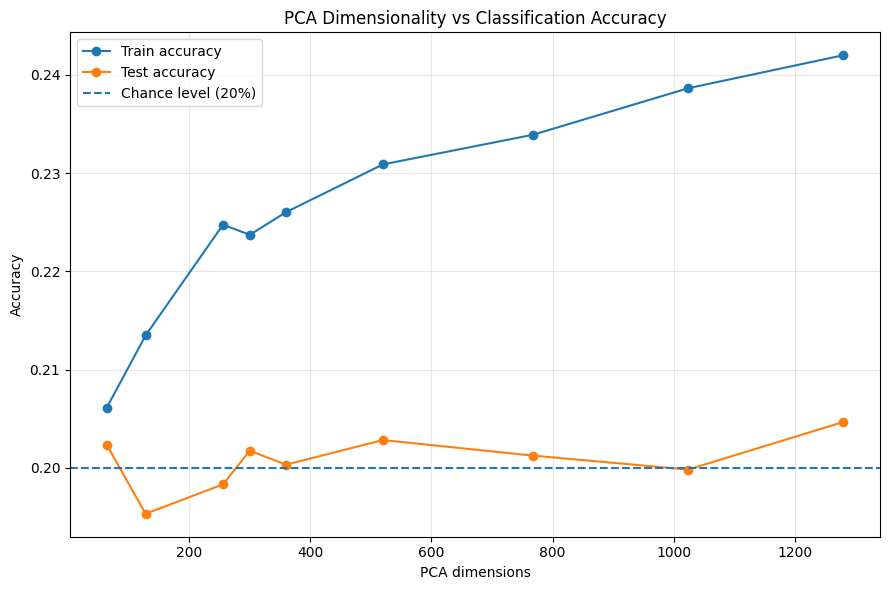

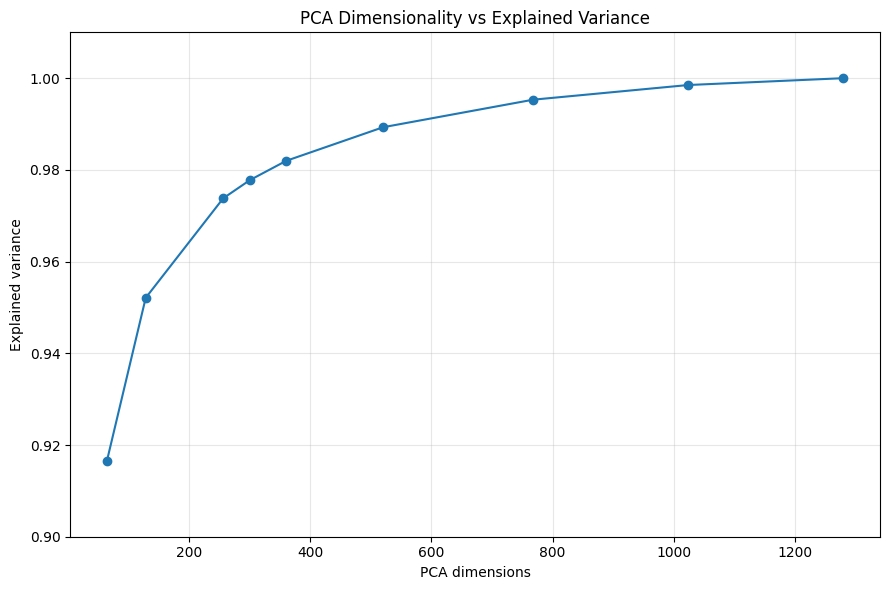

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# PCA results
pca_results_df = pd.DataFrame({
    "D": [64, 128, 256, 300, 360, 520, 768, 1024, 1280],
    "train_accuracy": [
        0.206146, 0.213479, 0.224750, 0.223708, 0.226021,
        0.230875, 0.233896, 0.238625, 0.241979
    ],
    "test_accuracy": [
        0.202333, 0.195333, 0.198333, 0.201750, 0.200333,
        0.202833, 0.201250, 0.199833, 0.204667
    ],
    "explained_variance": [
        0.91657394, 0.9520965, 0.97380584, 0.9777693,
        0.98197466, 0.98930174, 0.9953123, 0.99850905, 1.0000001
    ]
})

# --------------------------------------------------
# Plot 1: Dimensionality vs Accuracy
# --------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    pca_results_df["D"],
    pca_results_df["train_accuracy"],
    marker="o",
    label="Train accuracy"
)

plt.plot(
    pca_results_df["D"],
    pca_results_df["test_accuracy"],
    marker="o",
    label="Test accuracy"
)

plt.axhline(
    0.20,
    linestyle="--",
    label="Chance level (20%)"
)

plt.xlabel("PCA dimensions")
plt.ylabel("Accuracy")
plt.title("PCA Dimensionality vs Classification Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 2: Dimensionality vs Explained Variance
# --------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    pca_results_df["D"],
    pca_results_df["explained_variance"],
    marker="o"
)

plt.xlabel("PCA dimensions")
plt.ylabel("Explained variance")
plt.title("PCA Dimensionality vs Explained Variance")
plt.ylim(0.90, 1.01)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ESM-2 Embedding Dimensionality Analysis

## Objective

The ESM-2 model (`facebook/esm2_t33_650M_UR50D`) produces a **1280-dimensional embedding** for each protein sequence.

The objective of this experiment is to determine whether reducing the embedding dimensionality affects classification performance and to identify a practical reduced dimensionality for downstream experiments.

The classification task contains five approximately balanced protein classes:

- **Enzima**
- **Estrutural**
- **Outras**
- **Receptora**
- **Transporte**

The dataset contains **60,000 protein sequences**. An 80/20 stratified split was used:

- Training: 48,000 sequences
- Test: 12,000 sequences

Because there are five balanced classes, random classification corresponds to approximately **20% accuracy**.

---

## Experimental Setup

The original ESM-2 representation has:

- Embedding dimensionality: **1280**
- Model: `facebook/esm2_t33_650M_UR50D`
- Pooling: masked mean pooling
- Maximum sequence length: 512 tokens

PCA was used to investigate whether the 1280-dimensional representation could be compressed without affecting downstream classification.

The following dimensionalities were evaluated:

**64, 128, 256, 300, 360, 520, 768, 1024, and 1280 dimensions.**

For every dimensionality, the same train/test split and classification procedure were used.

---

## PCA Results

| Dimensions | Train Accuracy | Test Accuracy | Explained Variance |
|---:|---:|---:|---:|
| 64 | 20.61% | 20.23% | 91.66% |
| 128 | 21.35% | 19.53% | 95.21% |
| 256 | 22.48% | 19.83% | 97.38% |
| 300 | 22.37% | 20.18% | 97.78% |
| 360 | 22.60% | 20.03% | 98.20% |
| 520 | 23.09% | 20.28% | 98.93% |
| 768 | 23.39% | 20.13% | 99.53% |
| 1024 | 23.86% | 19.98% | 99.85% |
| 1280 | 24.20% | 20.47% | 100.00% |

---

## Explained Variance

The PCA results show that most of the variance in the original ESM-2 representation is concentrated in a relatively small number of dimensions.

At **256 dimensions**, PCA retains:

**97.38% of the original variance.**

At **360 dimensions**, it retains:

**98.20%.**

At **520 dimensions**, it retains:

**98.93%.**

At **768 dimensions**, it retains:

**99.53%.**

Therefore, the 1280-dimensional representation contains substantial redundancy from the perspective of total variance.

---

## Classification Performance

The classification results tell a different story.

Despite the large increase in explained variance as dimensionality increases, test accuracy remains approximately at the **20% chance level**.

For example:

- 64D → 20.23% test accuracy
- 256D → 19.83%
- 360D → 20.03%
- 520D → 20.28%
- 768D → 20.13%
- 1024D → 19.98%
- 1280D → 20.47%

There is therefore no clear relationship between retaining more PCA variance and improving classification performance.

This is an important result.

### Explained variance does not equal discriminative information

A representation can preserve a large amount of its statistical variance while still failing to preserve information that is useful for the particular classification task.

In this experiment:

> **97.38% of the embedding variance can be retained at 256 dimensions, but classification accuracy remains close to the 20% chance level.**

This indicates that the dimensions removed by PCA do not appear to contain substantial additional information for the current classification task.

---

## Training Accuracy

Training accuracy also remains low across all dimensionalities.

It increases from approximately **20.6% at 64D** to approximately **24.2% at 1280D**.

This is important because the model is not showing the typical pattern of strong overfitting where training accuracy is high but test accuracy is low.

Instead, both training and test accuracy remain close to chance.

This suggests that the classifier is currently struggling to learn a discriminative relationship between the ESM-2 representations and the five target classes.

---

## Selecting the Reduced Dimensionality

The original ESM-2 embedding dimensionality remains:

**1280 dimensions**

It is important not to redefine this as 256 dimensions.

Instead, we distinguish between:

- `d_embedding = 1280` — original ESM-2 representation
- `d_reduced = 256` — PCA representation used for downstream experiments

### Why 256 dimensions?

256D provides a practical balance between dimensionality reduction and information retention.

It reduces the representation from:

**1280 → 256 dimensions**

which corresponds to an **80% reduction in dimensionality**, while retaining:

**97.38% of the original PCA variance.**

Increasing the dimensionality beyond 256 provides only modest additional variance retention and does not produce a meaningful improvement in classification accuracy.

For example:

| Dimensions | Additional Variance vs 256D | Test Accuracy |
|---:|---:|---:|
| 256 | — | 19.83% |
| 300 | +0.40 percentage points | 20.18% |
| 360 | +0.82 percentage points | 20.03% |
| 520 | +1.55 percentage points | 20.28% |
| 768 | +2.15 percentage points | 20.13% |
| 1024 | +2.47 percentage points | 19.98% |
| 1280 | +2.62 percentage points | 20.47% |

The small differences in accuracy are not sufficient to justify retaining substantially more dimensions at this stage.

---

## Selected Representation

For subsequent experiments, the representation will therefore be defined as:

**Original representation**

`ESM-2 → 1280D`

**Reduced representation**

`ESM-2 → PCA → 256D`

The 1280D representation will remain available as the reference/control representation.

The 256D representation will be used as the primary compact representation for downstream experiments.

---

## Main Finding

The dimensionality experiment provides evidence that **dimensionality reduction is not the primary explanation for the approximately 20% classification performance**.

Increasing the representation from 256D to the full 1280D representation does not produce a meaningful improvement in test accuracy.

The results therefore suggest that the investigation should move beyond simply increasing embedding dimensionality.

The current evidence points toward other possible factors, including:

- the quality of the sequence-level ESM-2 representation for this classification task
- the mean-pooling strategy
- sequence truncation at 512 residues
- the biological relationship between the five classes
- classifier architecture
- optimization behaviour
- the underlying class labels and their relationship to sequence information

---

## Experimental Decision

For the remainder of the dimensionality experiments:

> **Use 1280D as the original ESM-2 embedding dimensionality and 256D as the primary PCA-reduced representation.**

The 300D and 360D configurations can be retained as sensitivity-analysis configurations, but there is currently no evidence that they provide a meaningful advantage over 256D.

---

## Next Step: Raw ESM-2 Control

The next experiment should test the original 1280-dimensional embeddings directly, without PCA or learned projection.

The control experiment is therefore:

**ESM-2 1280D → Linear Classifier → 5 Classes**

This experiment is important because it will determine whether the approximately 20% performance is caused by the dimensionality-reduction pipeline or whether the same limitation exists in the original ESM-2 representation.

If the raw 1280D representation also remains close to 20% accuracy, the investigation should shift toward the representation, pooling, sequence preprocessing, labels, and biological separability rather than dimensionality reduction.